# LECTURE 19
**Topic:** Orthogonality of Fourier Sinusoids; Determination of Fourier Series Coefficients  

---

## Key Points

- CT inner product: $\langle f,g\rangle = \frac{1}{T_0}\int_0^{T_0}f^*(t)g(t)\,dt$
- Fourier sinusoids are **orthonormal**: $\langle v^{(k)},v^{(\ell)}\rangle = \delta_{k\ell}$
- Analysis equation: $S_k = \langle v^{(k)},s\rangle = \frac{1}{T_0}\int_0^{T_0}s(t)e^{-jk\Omega_0 t}\,dt$


---
## Theory and Examples

### 2–3. CT Inner Product

For complex-valued periodic signals $f(t)$ and $g(t)$ with common period $T_0$:
$$\langle f,g\rangle \stackrel{\text{def}}{=} \frac{1}{T_0}\int_0^{T_0}f^*(t)g(t)\,dt$$

Properties:
- $\langle g,f\rangle = \langle f,g\rangle^*$
- $\langle f,zg\rangle = z\langle f,g\rangle$
- Integration range can be **any** interval of length $T_0$.

### 4–5. Orthonormality of Fourier Sinusoids

$$\langle v^{(k)},v^{(\ell)}\rangle = \frac{1}{T_0}\int_0^{T_0}e^{j(\ell-k)\Omega_0 t}\,dt = \begin{cases}1 & k=\ell \\ 0 & k\neq\ell\end{cases}$$

**Proof for $k\neq\ell$:** $\int_0^{T_0}\cos((\ell-k)\Omega_0 t)\,dt=0$ (integral of $|\ell-k|$ full periods).

Note the difference with DFT: $\langle v^{(k)},v^{(\ell)}\rangle_{\text{DFT}}=N\delta_{k\ell}$ (norm is $\sqrt{N}$, not 1).

### 6. Analysis Equation

From $s=\sum_\ell S_\ell v^{(\ell)}$, taking inner product with $v^{(k)}$:
$$S_k = \langle v^{(k)},s\rangle = \frac{1}{T_0}\int_0^{T_0}s(t)e^{-jk\Omega_0 t}\,dt$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

# Verify orthonormality numerically
T0=1.0; Omega0=2*np.pi/T0
t=np.linspace(0,T0,10000,endpoint=False)
dt=T0/len(t)

print('Verifying <v^(k), v^(l)> = delta_kl:')
for k in range(-3,4):
    for l in range(-3,4):
        vk=np.exp(1j*k*Omega0*t)
        vl=np.exp(1j*l*Omega0*t)
        ip=(vk.conj()*vl*dt).sum()  # numerical integration
        expected=1.0 if k==l else 0.0
        if not np.isclose(abs(ip),expected,atol=1e-6):
            print(f'  k={k},l={l}: {ip:.6f}  ERROR!')
print('  All checked (no errors = all inner products match delta_kl)')

Verifying <v^(k), v^(l)> = delta_kl:
  All checked (no errors = all inner products match delta_kl)


---
### 7. Example: Rectangular Pulse Train

Signal: pulse of height 1, width $\alpha T_0$, centered at $t=0$.

**DC coefficient ($k=0$):**
$$S_0=\frac{1}{T_0}\int_0^{T_0}s(t)\,dt=\frac{\alpha T_0}{T_0}=\alpha$$

**Fourier coefficients ($k\neq 0$):**
$$S_k=\frac{1}{T_0}\int_{-\alpha T_0/2}^{\alpha T_0/2}e^{-jk\Omega_0 t}\,dt=\frac{\sin(k\alpha\pi)}{k\pi}=\alpha\,\text{sinc}(k\alpha)$$

Note: $S_{-k}=S_k$ (real and even coefficients, since $s(t)$ is real and even).

The **sinc function** $\text{sinc}(x)=\sin(\pi x)/(\pi x)$ (normalized) or $\sin(x)/x$ (unnormalized).

For $\alpha=1/2$: $S_k=\sin(k\pi/2)/(k\pi)$. For odd $k$: $\pm 1/(k\pi)$; for even $k$: 0.

### 10. Example: Piecewise Constant Waveform

$x(t)$ of period $T_0=6$: use linearity — express as sum of rectangular pulse trains.

$X_0=2+2/3+2\cdot 1/3=10/3$; $X_k=\frac{\sin(2k\pi/3)}{k\pi}+\frac{2\sin(k\pi/3)}{k\pi}$


=== alpha = 0.5 ===
  S_k = sin(k*0.5*pi)/(k*pi):
    k= -9: Sk=0.0354
    k= -7: Sk=-0.0455
    k= -5: Sk=0.0637
    k= -3: Sk=-0.1061
    k= -1: Sk=0.3183
    k=  0: Sk=0.5000
    k=  1: Sk=0.3183
    k=  3: Sk=-0.1061
    k=  5: Sk=0.0637
    k=  7: Sk=-0.0455
    k=  9: Sk=0.0354

=== alpha = 0.25 ===
  S_k = sin(k*0.25*pi)/(k*pi):
    k=-10: Sk=0.0318
    k= -9: Sk=0.0250
    k= -7: Sk=-0.0322
    k= -6: Sk=-0.0531
    k= -5: Sk=-0.0450
    k= -3: Sk=0.0750
    k= -2: Sk=0.1592
    k= -1: Sk=0.2251
    k=  0: Sk=0.2500
    k=  1: Sk=0.2251
    k=  2: Sk=0.1592
    k=  3: Sk=0.0750
    k=  5: Sk=-0.0450
    k=  6: Sk=-0.0531
    k=  7: Sk=-0.0322
    k=  9: Sk=0.0250
    k= 10: Sk=0.0318



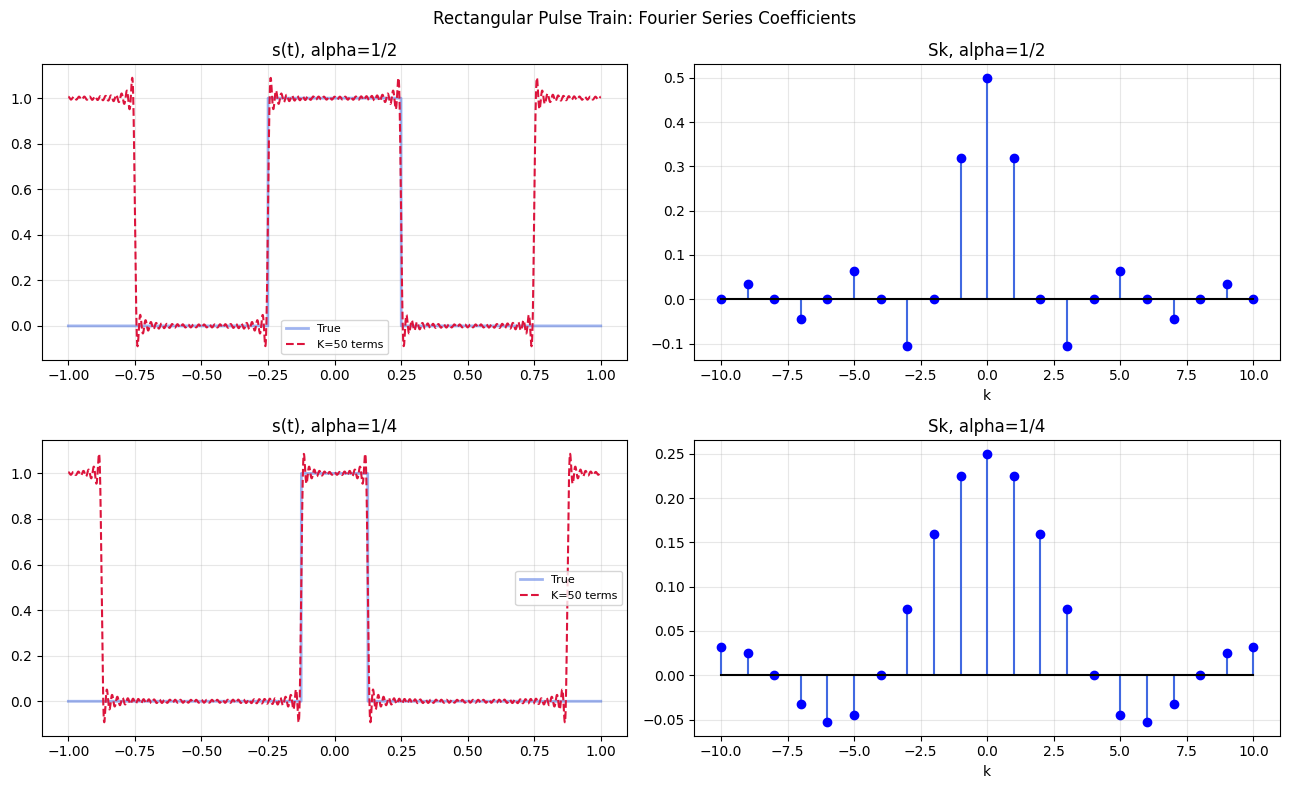

In [2]:
# Rectangular pulse train Fourier coefficients
for alpha in [0.5, 0.25]:
    print(f'=== alpha = {alpha} ===')
    ks=range(-10,11)
    Sk_formula=np.array([alpha if k==0 else np.sin(k*alpha*np.pi)/(k*np.pi) for k in ks])
    print(f'  S_k = sin(k*{alpha}*pi)/(k*pi):')
    for k,sk in zip(ks,Sk_formula):
        if abs(sk)>0.01:
            print(f'    k={k:3d}: Sk={sk:.4f}')
    print()

# Visualize
fig,axes=plt.subplots(2,2,figsize=(13,8))
T0=1.0; Omega0=2*np.pi
t=np.linspace(-T0,T0,1000)

for row,(alpha,label) in enumerate([(0.5,'alpha=1/2'),(0.25,'alpha=1/4')]):
    # Time domain (one period shown twice)
    s_t=np.where(np.abs(t%T0-0.5*T0)<alpha*T0/2+1e-10, 1.0, 0.0)
    # Better: use symmetric definition
    t2=np.linspace(-T0,T0,2000); s_t2=(np.abs(t2)<=alpha*T0/2).astype(float)
    # Reconstruct from Fourier series
    s_recon=np.ones_like(t2)*alpha
    for k in range(1,51):
        sk=np.sin(k*alpha*np.pi)/(k*np.pi)
        s_recon+=2*sk*np.cos(k*Omega0*t2)
    axes[row][0].plot(t2/T0,s_t2,'royalblue',lw=2,alpha=0.5,label='True')
    axes[row][0].plot(t2/T0,s_recon,'crimson',lw=1.5,ls='--',label='K=50 terms')
    axes[row][0].set_title(f's(t), {label}'); axes[row][0].legend(fontsize=8); axes[row][0].grid(True,alpha=0.3)
    # Spectrum
    k_range=np.arange(-10,11)
    Sk=[alpha if k==0 else np.sin(k*alpha*np.pi)/(k*np.pi) for k in k_range]
    axes[row][1].stem(k_range,Sk,linefmt='royalblue',markerfmt='bo',basefmt='k')
    axes[row][1].set_title(f'Sk, {label}'); axes[row][1].set_xlabel('k'); axes[row][1].grid(True,alpha=0.3)
plt.suptitle('Rectangular Pulse Train: Fourier Series Coefficients', fontsize=12)
plt.tight_layout(); plt.show()

X0 (DC) = (5*2+3*2+2*2)/6 = 3.3333 (formula: 10/3=3.3333)
Xk values:
  k= -5: Xk=-0.1654
  k= -4: Xk=-0.0689
  k= -3: Xk=0.0000
  k= -2: Xk=0.1378
  k= -1: Xk=0.8270
  k=  0: Xk=3.3333
  k=  1: Xk=0.8270
  k=  2: Xk=0.1378
  k=  3: Xk=0.0000
  k=  4: Xk=-0.0689
  k=  5: Xk=-0.1654


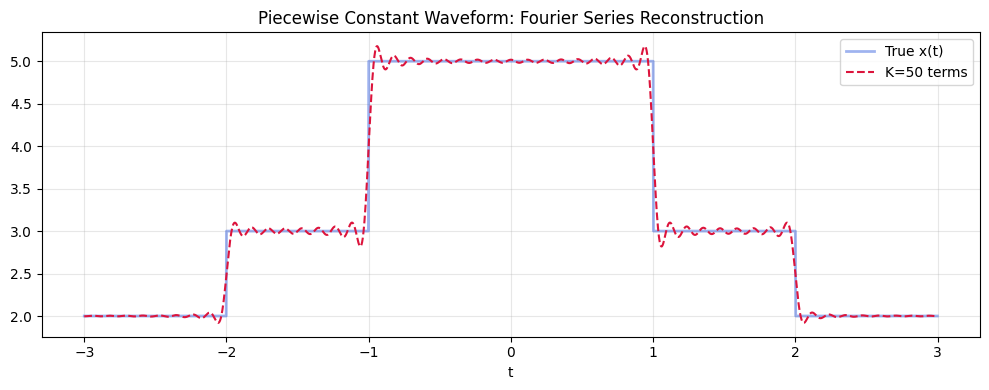

In [3]:
# Piecewise constant example: x(t) period T0=6
# x(t) = 5 on [-1,1], 3 on [1,2] and [-2,-1], 2 on [2,3] and [-3,-2]
# Express as sum of rectangular pulse trains
# Pulse train 1: height 2, width 6 (full period) -> contribution = 2 everywhere
# Pulse train 2: height 1, width 4 (alpha=2/3) centered at 0 -> contribution on [-2,2]
# Actually from lecture: X0=2+2/3+2*(1/3)=10/3
# Xk = sin(2k*pi/3)/(k*pi) + 2*sin(k*pi/3)/(k*pi)

T0=6; Omega0=2*np.pi/T0
t=np.linspace(-3,3,3000,endpoint=False)

# True x(t)
x_true=np.where(np.abs(t)<=1, 5, np.where(np.abs(t)<=2, 3, 2)).astype(float)

# Fourier coefficients
def Xk(k):
    if k==0: return 10/3
    return np.sin(2*k*np.pi/3)/(k*np.pi) + 2*np.sin(k*np.pi/3)/(k*np.pi)

# Verify DC: mean of x(t) over one period
# x(t) = 5 on length 2, 3 on length 2, 2 on length 2 -> mean = (5*2+3*2+2*2)/6=20/6=10/3
print(f'X0 (DC) = (5*2+3*2+2*2)/6 = {(5*2+3*2+2*2)/6:.4f} (formula: 10/3={10/3:.4f})')
print('Xk values:')
for k in range(-5,6):
    print(f'  k={k:3d}: Xk={Xk(k):.4f}')

# Reconstruct
x_recon=np.zeros_like(t, dtype=float)
K_max=50
for k in range(-K_max,K_max+1):
    x_recon+=Xk(k)*np.exp(1j*k*Omega0*t).real

fig,ax=plt.subplots(figsize=(10,4))
ax.plot(t,x_true,'royalblue',lw=2,alpha=0.5,label='True x(t)')
ax.plot(t,x_recon,'crimson',lw=1.5,ls='--',label=f'K={K_max} terms')
ax.set_xlabel('t'); ax.set_title('Piecewise Constant Waveform: Fourier Series Reconstruction')
ax.legend(); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.show()

---
## Summary

| Formula | Description |
|---|---|
| $\langle f,g\rangle = \frac{1}{T_0}\int_0^{T_0}f^*g\,dt$ | CT inner product |
| $\langle v^{(k)},v^{(\ell)}\rangle=\delta_{k\ell}$ | Orthonormality |
| $S_k=\frac{1}{T_0}\int_0^{T_0}s(t)e^{-jk\Omega_0 t}\,dt$ | Analysis equation |
| Rect pulse: $S_k=\frac{\sin(k\alpha\pi)}{k\pi}$ | Closed-form result |

### Mistakes to Avoid
1. CT Fourier sinusoids are **unit norm** ($\langle v^{(k)},v^{(k)}\rangle=1$), unlike DFT where $\langle v^{(k)},v^{(k)}\rangle=N$.
2. Integration range can be **any** $T_0$-length interval — not just $[0,T_0)$.
3. $S_{-k}=S_k$ (real and even) only when $s(t)$ is real AND even. For just real: $S_{-k}=S_k^*$.
